Setup, W&B & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import wandb

# Inisialisasi W&B
run = wandb.init(project="titanic-classification", name="logistic-regression-baseline")

# Load dataset Titanic
df = sns.load_dataset("titanic")

print("Dataset Shape:", df.shape)
df.head()

df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]

df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)

wandb.log({"raw_data": wandb.Table(dataframe=df.head(100))})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sitiyolandahareniza (sitiyolandahareniza-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset Shape: (891, 15)


/tmp/ipykernel_1561/3173054715.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1561/3173054715.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Cek Keseimbangan Kelas & Split Data

/tmp/ipykernel_1561/2970289383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='Set2')


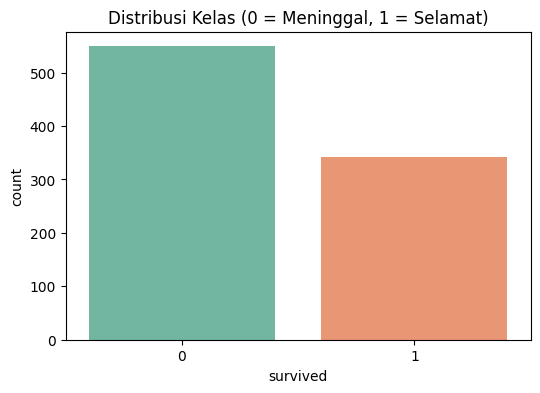

In [2]:
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df, palette='Set2')
plt.title("Distribusi Kelas (0 = Meninggal, 1 = Selamat)")
plt.show()

X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

wandb.config.update({"test_size": 0.3, "random_state": 42})

Training Model

In [3]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Training selesai!")

Training selesai!


Prediksi & Evaluasi Metrik

In [4]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

wandb.log({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1_Score": f1
})

print("--- Hasil Evaluasi Model ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

--- Hasil Evaluasi Model ---
Accuracy : 0.7985
Precision: 0.7426
Recall   : 0.7282
F1-Score : 0.7353


Confusion Matrix Visualization

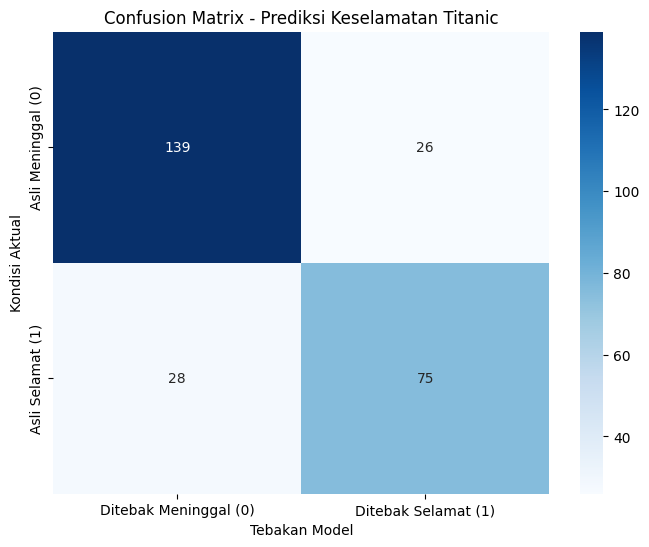


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       165
           1       0.74      0.73      0.74       103

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



Accuracy,▁
F1_Score,▁
Precision,▁
Recall,▁
Accuracy,0.79851
F1_Score,0.73529
Precision,0.74257
Recall,0.72816


In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ditebak Meninggal (0)', 'Ditebak Selamat (1)'],
            yticklabels=['Asli Meninggal (0)', 'Asli Selamat (1)'])

plt.title('Confusion Matrix - Prediksi Keselamatan Titanic')
plt.ylabel('Kondisi Aktual')
plt.xlabel('Tebakan Model')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

wandb.finish()